In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

Extracted Spatial Field 'a' Shape: (16384, 1)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (16384, 1)


E0704 12:33:30.575460  202543 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0704 12:33:30.586281  202431 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


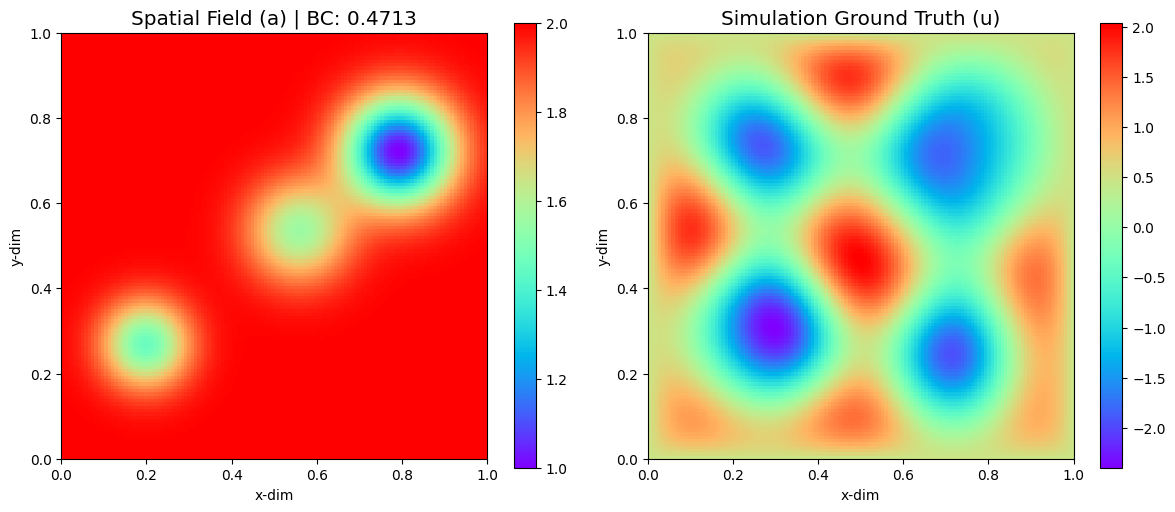

In [4]:
# Visualization (Mirroring your original plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting 'a' (the spatial dependent function)
im1 = axes[0].imshow(a_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im1, ax=axes[0])
axes[0].set_title(f'Spatial Field (a) | BC: {bc_sample:.4f}', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

# Plotting 'u' (the solution)
im2 = axes[1].imshow(u_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [5]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [6]:
epochs = 500
M = 512 
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] 
total_features = (2 * M) + sum(hidden_layers) # 1024
# total_features = hidden_layers[-1]

sigma = 3.0 
tik_reg_fixed = 1e-4 
pde_weight = 1
bc_weight = 1e10
data_weight = 1

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class ConcatFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        # 1. Start with the 1024 RFF features
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            # 2. Append each of the 256-feature hidden layers
            all_features.append(h)
            
        # 3. Concatenate everything together
        combined_h = jnp.concatenate(all_features)
        
        # 4. Return the full 2048-feature vector directly to the dynamic solver
        return combined_h

# class FeatureExtractor(nn.Module):
#     hidden_layers: list
#     B_matrix_base: jnp.ndarray 
    
#     @nn.compact
#     def __call__(self, x_in, y_in):    
#         # 1. Start with the high-frequency bandwidth you proved works
#         raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
#         sigma = jax.nn.softplus(raw_sigma)
          
#         v = jnp.concatenate([x_in, y_in])
#         proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
#         h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

#         for size in self.hidden_layers:
#             h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
#             h = jnp.sin(h) 
            
#         # 2. Return ONLY the final 256 features for the solver
#         return h 

# Don't forget to pass B_matrix_base instead of a pre-multiplied B_matrix
model = ConcatFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_xx, u_yy

# VMAPs reverted
f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)
omega = 5.0 * jnp.pi / 2.0 

def get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        f_chunk = f_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # a_pde is applied mathematically to the output features here
        A_pde_chunk = f_xx + f_yy + (omega**2) * a_pde * f_chunk
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(bc_weight)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    
    b_pde = jnp.zeros_like(a_pde)
    b_bc = bc_val_arr * jnp.sqrt(bc_weight)
    b_full = jnp.vstack([b_pde, b_bc])
    
    return A_full, b_full

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def solve_w(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A, b = get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
    Atb = A.T @ b
    return jnp.linalg.solve(AtA, Atb)

def compute_loss(params, w_current, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch):
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    # a_batch is applied mathematically to the physics calculation here
    pde_residual = laplacian_u + (omega**2) * a_batch * u_pred_interior
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    # 1. Calculate the true, unscaled mathematical errors for reporting
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    # 2. Apply the scaling weights for the optimizer
    loss_pde_scaled = loss_pde_unscaled * pde_weight
    loss_bc_scaled = loss_bc_unscaled * bc_weight
    loss_data_scaled = loss_data_unscaled * data_weight
    
    # 3. Sum total_loss using the SCALED components so gradients stay balanced
    total_loss = loss_pde_scaled + loss_bc_scaled + loss_data_scaled
    
    # 4. Return the UNSCALED components in the auxiliary tuple for accurate printing
    return total_loss, (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

def full_step(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    w_current = solve_w(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    (loss, aux_losses) = compute_loss(params, w_current, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch)
    return loss, aux_losses

loss_grad_fn = jax.jit(
    value_and_grad(full_step, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    (loss, aux_losses), grads = loss_grad_fn(
        params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size
    )
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss, aux_losses

In [9]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 5000
loss_history = []

for epoch in tqdm(range(epochs), desc="Overfitting Single Sample"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    a_chunk = a_flat[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss, (l_pde, l_bc, l_data) = update_network(
        params, opt_state, x_chunk, y_chunk, a_chunk, x_bc, y_bc, bc_val_array, u_chunk, total_features, chunk_size
    )
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Total: {loss:.4e} | PDE: {l_pde:.4e} | BC: {l_bc:.4e} | Data: {l_data:.4e}")

Overfitting Single Sample:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0 | Total: 3.2784e+00 | PDE: 6.5097e-01 | BC: 9.7723e-11 | Data: 1.6502e+00
Epoch 100 | Total: 2.5684e+00 | PDE: 3.4622e-01 | BC: 5.9026e-11 | Data: 1.6320e+00
Epoch 200 | Total: 2.3382e+01 | PDE: 1.5334e+01 | BC: 6.3753e-10 | Data: 1.6726e+00
Epoch 300 | Total: 1.0087e+01 | PDE: 5.2215e+00 | BC: 3.2192e-10 | Data: 1.6464e+00
Epoch 400 | Total: 7.1621e+00 | PDE: 3.4579e+00 | BC: 2.0206e-10 | Data: 1.6835e+00


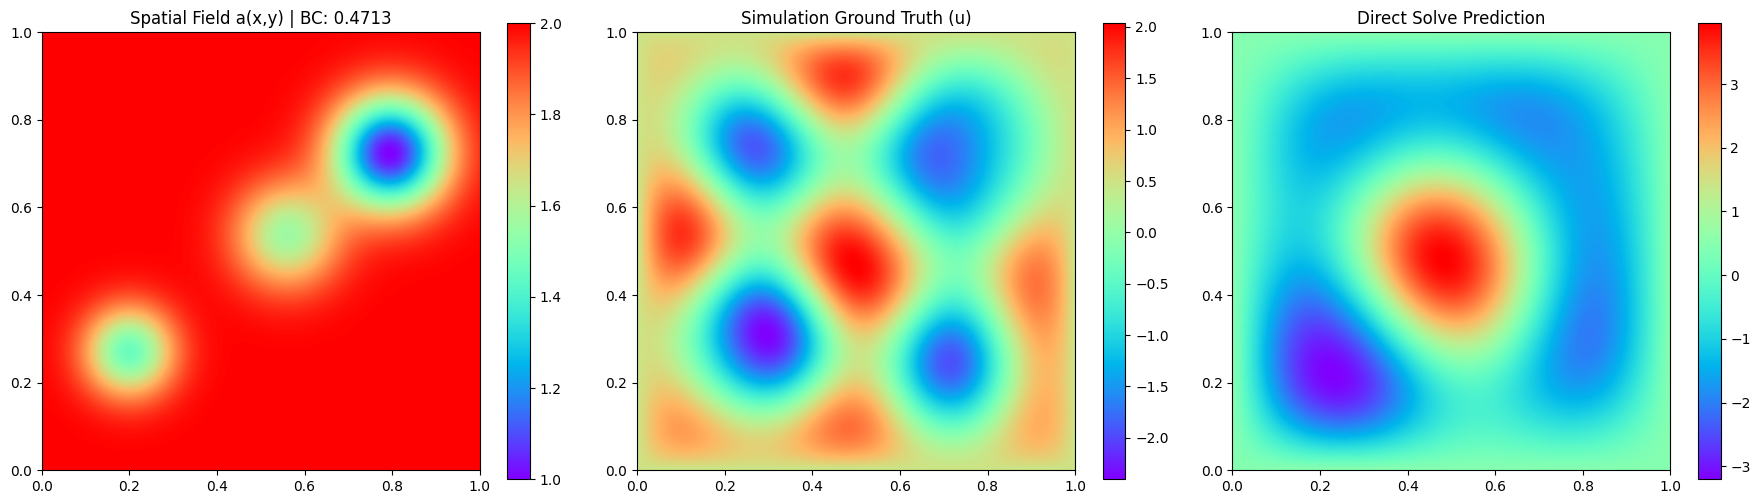

In [10]:
w_final = solve_w(params, x, y, a_flat, x_bc, y_bc, bc_val_array, total_features, chunk_size)
f_full = f_spatial_vmap(params, x, y)
u_pred_full = jnp.dot(f_full, w_final)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Direct Solve Prediction')

plt.tight_layout()
plt.show()